In [1]:
import numpy as np

#Define network

이전 주차의 TwoLayerNet에서 레이어 수, 가중치 초기화 및 감소, dropout, batchnorm 기능을 추가하였습니다.

**self.__init_weight()**과 **self.loss()**의 빈칸을 채워주세요!

In [ ]:
from collections import OrderedDict # 실행순서 보장

class MultiLayerNet:
    '''
    input_size: 입력 크기 (MNIST의 경우 784)
    hidden_size_list: 은닉층 뉴런 개수의 리스트 (예: [100,100,100]), 3개의 은닉층, 각 층의 뉴런 수는 100개
    output_size: 출력 크기 (MNIST의 경우 10)
    activation: 'relu' 또는 'sigmoid'
    weight_init_std: 가중치의 표준 편차 지정 (예: 0.01)
    'relu' 또는 'he'를 지정하면 He 초기화를 설정
    'sigmoid' 또는 'xavier'를 지정하면 Xavier 초기화를 설정
    weight_decay_lambda: Weight Decay(L2 정규화)의 강도
    use_dropout: Dropout을 사용할지 여부
    dropout_ration: Dropout 비율
    use_batchNorm: Batch Normalization을 사용할지 여부
    '''

    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0, # 활성화 함수는 relu, 가중치 초기값은 He 초기화, weight decay는 0 (사용하지 않음)
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False): # dropout은 사용하지 않음, batch normalization은 사용하지 않음
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        self.__init_weight(weight_init_std)

        # 레이어 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()


    def __init_weight(self, weight_init_std):
        """가중치 초기값 설정
        weight_init_std : 가중치의 표준 편차 지정 (예: 0.01)
        'relu' 또는 'he'를 지정하면 "He 초기화"를 설정
        'sigmoid' 또는 'xavier'를 지정하면 "Xavier 초기화"를 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx-1])  # ReLU, He 초기화, all_size_list[idx-1]는 input_size
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx-1])  # sigmoid, Xavier 초기화
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])


    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x


    def loss(self, x, t, train_flg=False):
        """손실 함수 정의
        입력 값 x는 입력 데이터, t는 정답 레이블
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay


    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy


    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)


        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

sigmoid 계층이 추가되었습니다.

In [4]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [5]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [6]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [7]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [8]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

In [9]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

Adam optimizer가 추가되었습니다.

In [10]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [11]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [12]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [13]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1  # momentum
        self.beta2 = beta2  # adagrad
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        # 시간에 따른 학습률 변화
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)


        for key in params.keys():
            self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

# Regularization

**BatchNormalization**

배치 단위로 정규화하고, 감마와 베타의 기울기를 구하는 과정을 살펴보세요.

계산 그래프에서 dx가 전달되는 과정을 알게 쉽게 설명한 글입니다!

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

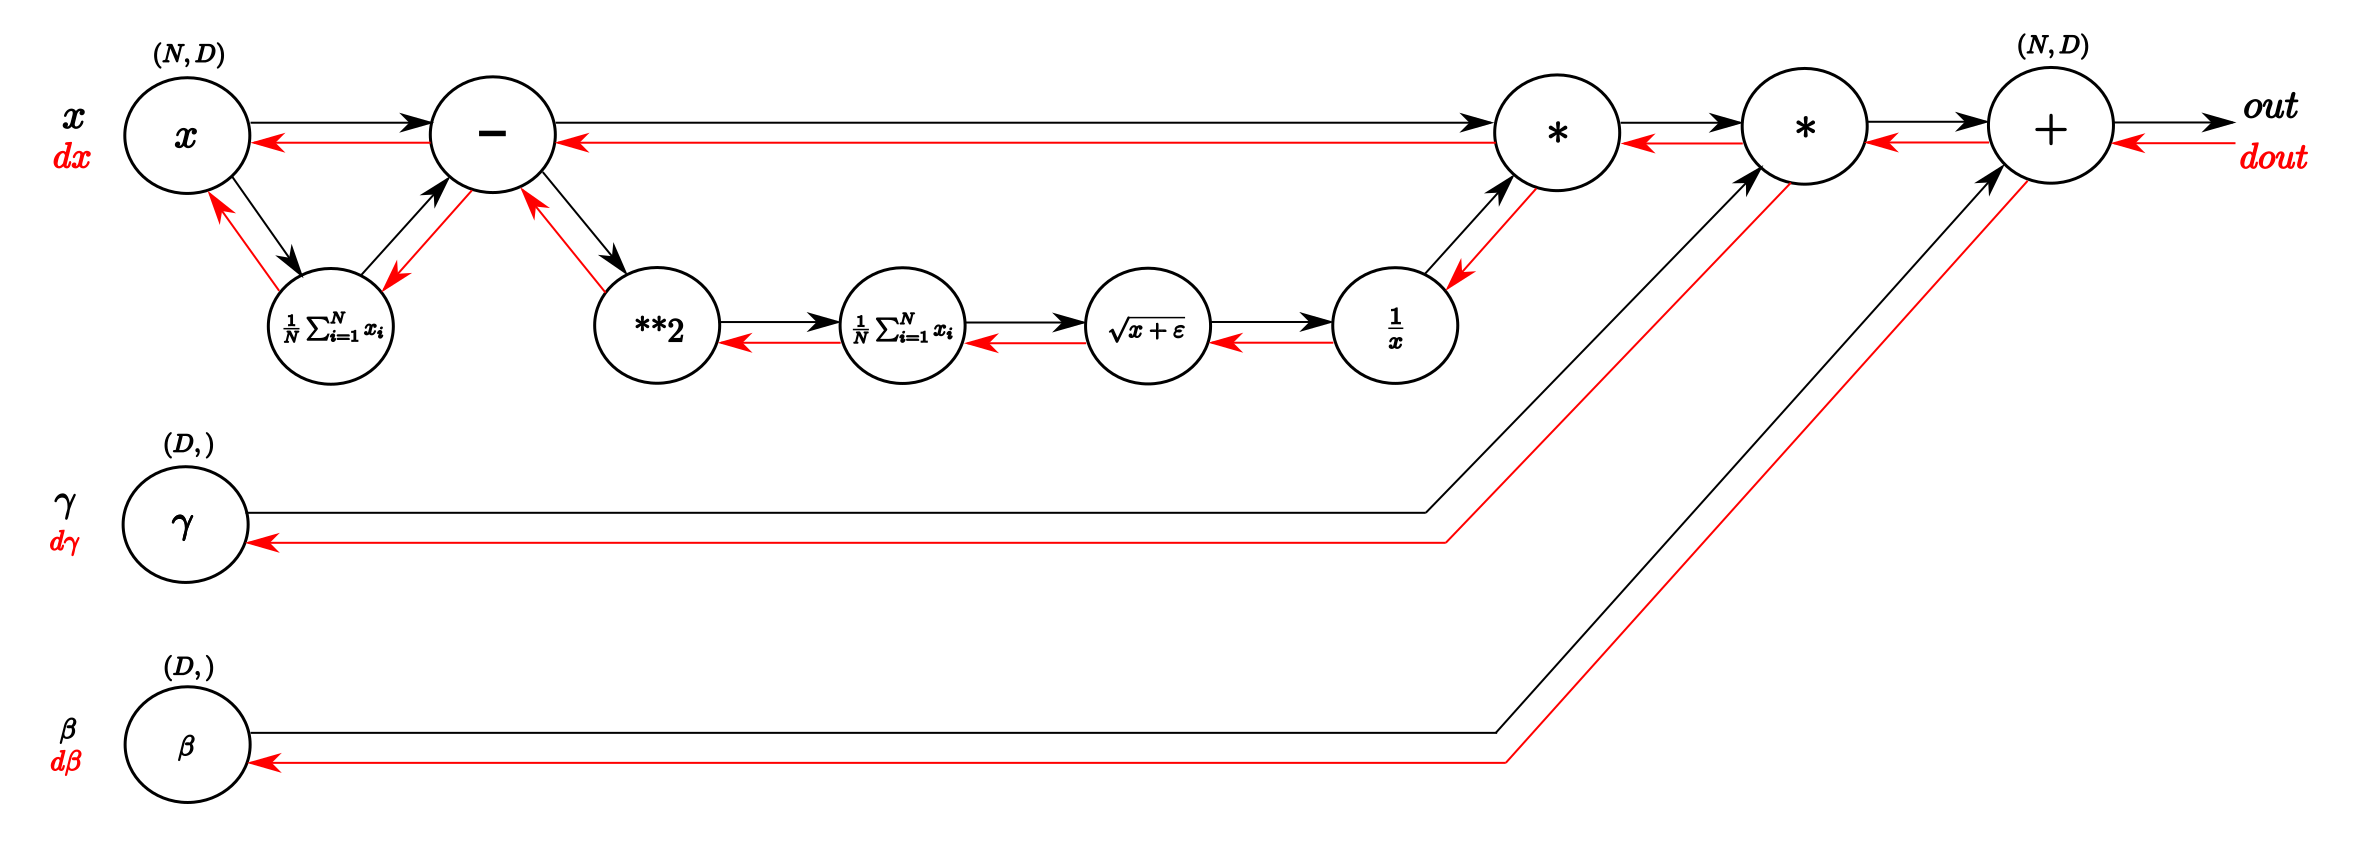

In [14]:
class BatchNormalization:
  """
  http://arxiv.org/abs/1502.03167
  """
  def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
      self.gamma = gamma
      self.beta = beta
      self.momentum = momentum
      self.input_shape = None # Conv 층=4차원, 완전 연결층=2차원

      # 테스트 시 사용하는 평균과 분산(즉, 업데이트 대상)
      self.running_mean = running_mean
      self.running_var = running_var

      # backward 시에 사용하는 중간 데이터
      self.batch_size = None
      self.xc = None
      self.std = None
      self.dgamma = None
      self.dbeta = None

  def forward(self, x, train_flg=True):
      self.input_shape = x.shape
      if x.ndim != 2:
          N, C, H, W = x.shape
          x = x.reshape(N, -1)

      out = self.__forward(x, train_flg)

      return out.reshape(*self.input_shape)


  def __forward(self, x, train_flg):
      if self.running_mean is None:
          N, D = x.shape
          self.running_mean = np.zeros(D)
          self.running_var = np.zeros(D)

      if train_flg:
          mu = x.mean(axis=0)
          xc = x - mu
          var = np.mean(xc**2, axis=0)
          std = np.sqrt(var + 10e-7)
          xn = xc / std

          self.batch_size = x.shape[0]
          self.xc = xc
          self.xn = xn
          self.std = std
          # 평균과 분산의 이동 평균 계산
          self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
          self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
      else:
          # 추론 과정
          xc = x - self.running_mean
          xn = xc / ((np.sqrt(self.running_var + 10e-7)))

      out = self.gamma * xn + self.beta
      return out


  def backward(self, dout):
      if dout.ndim != 2:
          N, C, H, W = dout.shape
          dout = dout.reshape(N, -1)

      dx = self.__backward(dout)

      dx = dx.reshape(*self.input_shape)
      return dx


  def __backward(self, dout):
      dbeta = dout.sum(axis=0)
      dgamma = np.sum(self.xn * dout, axis=0)
      dxn = self.gamma * dout
      dxc = dxn / self.std
      dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
      dvar = 0.5 * dstd / self.std
      dxc += (2.0 / self.batch_size) * self.xc * dvar
      dmu = np.sum(dxc, axis=0)
      dx = dxc - dmu / self.batch_size

      self.dgamma = dgamma
      self.dbeta = dbeta

      return dx

**Dropout**

In [15]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

# Training

In [17]:
import ssl
import certifi

# certifi의 CA 인증서 묶음을 명시적으로 사용
ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

print("사용할 인증서 파일:", certifi.where())

사용할 인증서 파일: c:\Users\User\anaconda3\envs\d2l\Lib\site-packages\certifi\cacert.pem


In [18]:
from torchvision import datasets, transforms

cifar10_train = datasets.MNIST(root='./data', train=True, download=True)
cifar10_test = datasets.MNIST(root='./data', train=False, download=True)

# flatten, normalization
x_train = cifar10_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train = cifar10_train.targets
x_test = cifar10_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test = cifar10_test.targets

# y one-hot encodeing
n = len(np.unique(t_train))
t_train = np.eye(n)[t_train]
t_test = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')
print(f't_train.shape: {t_train.shape}')

100.0%
100.0%
100.0%
100.0%


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)


정규화 기법을 하나씩 적용해보고, 그렇지 않은 경우의 결과를 비교해보세요!

epoch:0, train acc:0.10333333333333333, test acc:0.1083
epoch:1, train acc:0.12666666666666668, test acc:0.1215
epoch:2, train acc:0.14333333333333334, test acc:0.129
epoch:3, train acc:0.16, test acc:0.1431
epoch:4, train acc:0.18666666666666668, test acc:0.1529
epoch:5, train acc:0.22333333333333333, test acc:0.1648
epoch:6, train acc:0.22333333333333333, test acc:0.1743
epoch:7, train acc:0.22666666666666666, test acc:0.1805
epoch:8, train acc:0.25333333333333335, test acc:0.1943
epoch:9, train acc:0.29333333333333333, test acc:0.2086
epoch:10, train acc:0.30666666666666664, test acc:0.2153
epoch:11, train acc:0.3466666666666667, test acc:0.2313
epoch:12, train acc:0.36666666666666664, test acc:0.2479
epoch:13, train acc:0.37, test acc:0.2542
epoch:14, train acc:0.39666666666666667, test acc:0.2643
epoch:15, train acc:0.41333333333333333, test acc:0.2759
epoch:16, train acc:0.42333333333333334, test acc:0.2892
epoch:17, train acc:0.46, test acc:0.315
epoch:18, train acc:0.4733333333

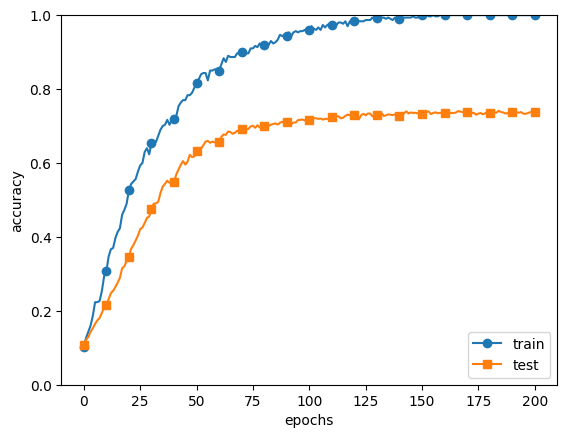

In [19]:
import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.07333333333333333, test acc:0.0932
epoch:1, train acc:0.08666666666666667, test acc:0.0917
epoch:2, train acc:0.11333333333333333, test acc:0.0988
epoch:3, train acc:0.13333333333333333, test acc:0.1053
epoch:4, train acc:0.15, test acc:0.1133
epoch:5, train acc:0.15333333333333332, test acc:0.1189
epoch:6, train acc:0.18333333333333332, test acc:0.1329
epoch:7, train acc:0.22666666666666666, test acc:0.1509
epoch:8, train acc:0.31333333333333335, test acc:0.1791
epoch:9, train acc:0.35, test acc:0.2079
epoch:10, train acc:0.39666666666666667, test acc:0.234
epoch:11, train acc:0.4266666666666667, test acc:0.2528
epoch:12, train acc:0.44666666666666666, test acc:0.2695
epoch:13, train acc:0.45666666666666667, test acc:0.28
epoch:14, train acc:0.4633333333333333, test acc:0.2916
epoch:15, train acc:0.4866666666666667, test acc:0.3058
epoch:16, train acc:0.4766666666666667, test acc:0.3104
epoch:17, train acc:0.48, test acc:0.316
epoch:18, train acc:0.483333333333333

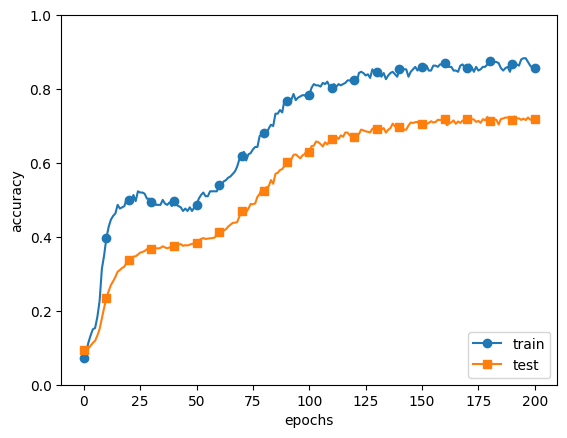

In [20]:
# weight decay를 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.15, test acc:0.127
epoch:1, train acc:0.15333333333333332, test acc:0.1243
epoch:2, train acc:0.17333333333333334, test acc:0.1267
epoch:3, train acc:0.14666666666666667, test acc:0.1238
epoch:4, train acc:0.14, test acc:0.1199
epoch:5, train acc:0.13333333333333333, test acc:0.1058
epoch:6, train acc:0.15, test acc:0.1084
epoch:7, train acc:0.14, test acc:0.1208
epoch:8, train acc:0.15333333333333332, test acc:0.1103
epoch:9, train acc:0.13333333333333333, test acc:0.1016
epoch:10, train acc:0.13, test acc:0.0986
epoch:11, train acc:0.13, test acc:0.0994
epoch:12, train acc:0.15333333333333332, test acc:0.1098
epoch:13, train acc:0.14333333333333334, test acc:0.1201
epoch:14, train acc:0.15666666666666668, test acc:0.1129
epoch:15, train acc:0.15, test acc:0.1094
epoch:16, train acc:0.15, test acc:0.11
epoch:17, train acc:0.15333333333333332, test acc:0.1133
epoch:18, train acc:0.14666666666666667, test acc:0.1252
epoch:19, train acc:0.15666666666666668, test acc:

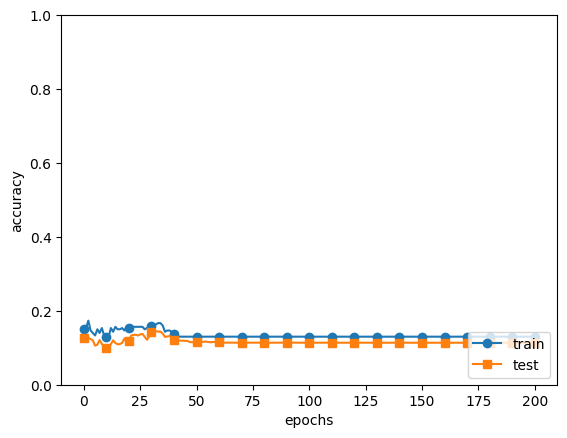

In [30]:
# dropout을 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = True, dropout_ration = 0.5, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.08333333333333333, test acc:0.0735
epoch:1, train acc:0.09333333333333334, test acc:0.0841
epoch:2, train acc:0.11666666666666667, test acc:0.0939
epoch:3, train acc:0.14333333333333334, test acc:0.112
epoch:4, train acc:0.23, test acc:0.1343
epoch:5, train acc:0.29, test acc:0.1628
epoch:6, train acc:0.43, test acc:0.2009
epoch:7, train acc:0.5433333333333333, test acc:0.2336
epoch:8, train acc:0.64, test acc:0.2656
epoch:9, train acc:0.71, test acc:0.2882
epoch:10, train acc:0.77, test acc:0.3087
epoch:11, train acc:0.8033333333333333, test acc:0.3197
epoch:12, train acc:0.85, test acc:0.329
epoch:13, train acc:0.8866666666666667, test acc:0.3387
epoch:14, train acc:0.9033333333333333, test acc:0.3471
epoch:15, train acc:0.9233333333333333, test acc:0.357
epoch:16, train acc:0.9166666666666666, test acc:0.3601
epoch:17, train acc:0.94, test acc:0.3709
epoch:18, train acc:0.95, test acc:0.3821
epoch:19, train acc:0.9566666666666667, test acc:0.389
epoch:20, train 

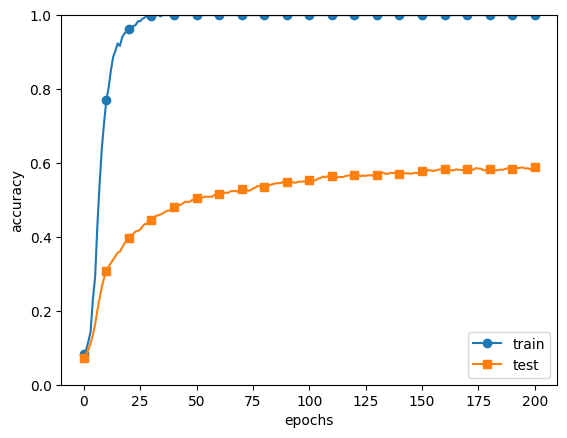

In [23]:
# batch normalization을 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                         weight_decay_lambda=0, use_dropout = False, dropout_ration = 0, use_batchnorm=True)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09333333333333334, test acc:0.1099
epoch:1, train acc:0.37, test acc:0.3059
epoch:2, train acc:0.6833333333333333, test acc:0.5989
epoch:3, train acc:0.77, test acc:0.62
epoch:4, train acc:0.8, test acc:0.6144
epoch:5, train acc:0.85, test acc:0.6653
epoch:6, train acc:0.91, test acc:0.7202
epoch:7, train acc:0.93, test acc:0.7224
epoch:8, train acc:0.9566666666666667, test acc:0.7641
epoch:9, train acc:0.9433333333333334, test acc:0.7362
epoch:10, train acc:0.98, test acc:0.7583
epoch:11, train acc:0.9833333333333333, test acc:0.7317
epoch:12, train acc:0.9866666666666667, test acc:0.7337
epoch:13, train acc:0.97, test acc:0.7145
epoch:14, train acc:0.9666666666666667, test acc:0.7389
epoch:15, train acc:0.9766666666666667, test acc:0.7444
epoch:16, train acc:0.98, test acc:0.7506
epoch:17, train acc:0.99, test acc:0.7642
epoch:18, train acc:0.9733333333333334, test acc:0.7817
epoch:19, train acc:0.9866666666666667, test acc:0.7842
epoch:20, train acc:0.98, test a

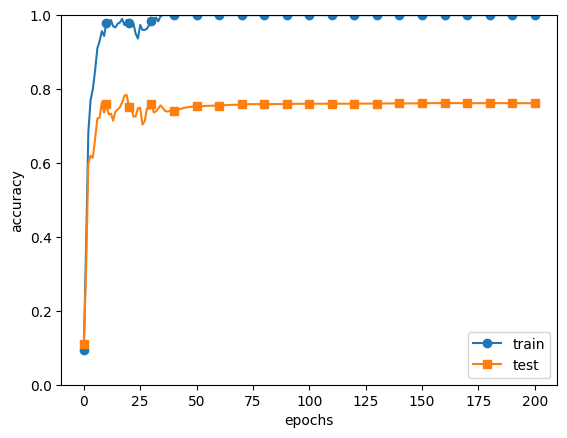

In [24]:
# optimizer를 Adam으로 바꾼 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


# optimizer = SGD(lr=0.01)
optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.1, test acc:0.0935
epoch:1, train acc:0.21666666666666667, test acc:0.1814
epoch:2, train acc:0.43666666666666665, test acc:0.4072
epoch:3, train acc:0.43666666666666665, test acc:0.3592
epoch:4, train acc:0.43, test acc:0.389
epoch:5, train acc:0.46, test acc:0.3956
epoch:6, train acc:0.47, test acc:0.3656
epoch:7, train acc:0.51, test acc:0.4288
epoch:8, train acc:0.5133333333333333, test acc:0.4192
epoch:9, train acc:0.47, test acc:0.3825
epoch:10, train acc:0.42333333333333334, test acc:0.3806
epoch:11, train acc:0.4666666666666667, test acc:0.4103
epoch:12, train acc:0.48333333333333334, test acc:0.4225
epoch:13, train acc:0.5366666666666666, test acc:0.4385
epoch:14, train acc:0.5066666666666667, test acc:0.3993
epoch:15, train acc:0.46, test acc:0.3583
epoch:16, train acc:0.47333333333333333, test acc:0.3951
epoch:17, train acc:0.5166666666666667, test acc:0.4285
epoch:18, train acc:0.48333333333333334, test acc:0.4062
epoch:19, train acc:0.52, test acc:0.44

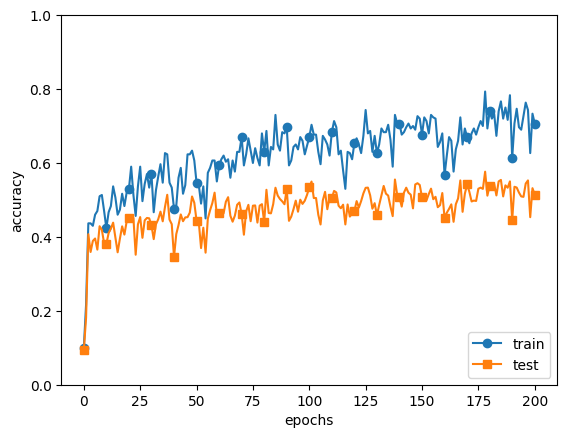

In [25]:
# optimizer를 Adam으로 바꾼 경우
# weight decay를 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


# optimizer = SGD(lr=0.01)
optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.09666666666666666, test acc:0.0975
epoch:1, train acc:0.09666666666666666, test acc:0.0958
epoch:2, train acc:0.10333333333333333, test acc:0.101
epoch:3, train acc:0.17666666666666667, test acc:0.1494
epoch:4, train acc:0.14, test acc:0.122
epoch:5, train acc:0.25666666666666665, test acc:0.2275
epoch:6, train acc:0.22333333333333333, test acc:0.2086
epoch:7, train acc:0.25333333333333335, test acc:0.2255
epoch:8, train acc:0.25, test acc:0.2133
epoch:9, train acc:0.2966666666666667, test acc:0.2459
epoch:10, train acc:0.30333333333333334, test acc:0.272
epoch:11, train acc:0.31, test acc:0.2789
epoch:12, train acc:0.3333333333333333, test acc:0.2896
epoch:13, train acc:0.33, test acc:0.2884
epoch:14, train acc:0.3333333333333333, test acc:0.2973
epoch:15, train acc:0.3466666666666667, test acc:0.2954
epoch:16, train acc:0.33666666666666667, test acc:0.2947
epoch:17, train acc:0.3333333333333333, test acc:0.2891
epoch:18, train acc:0.33666666666666667, test acc:0.

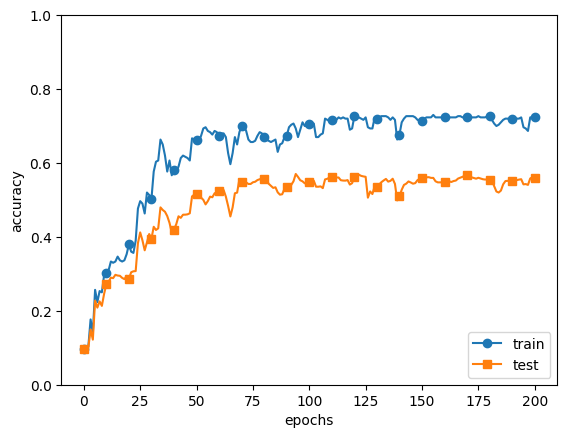

In [26]:
# optimizer를 Adam으로 바꾼 경우
# dropout을 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = True, dropout_ration = 0.5, use_batchnorm=False)


# optimizer = SGD(lr=0.01)
optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.12666666666666668, test acc:0.1605
epoch:1, train acc:0.33666666666666667, test acc:0.2707
epoch:2, train acc:0.5166666666666667, test acc:0.4061
epoch:3, train acc:0.63, test acc:0.5103
epoch:4, train acc:0.7, test acc:0.5712
epoch:5, train acc:0.88, test acc:0.6671
epoch:6, train acc:0.9666666666666667, test acc:0.7218
epoch:7, train acc:0.9833333333333333, test acc:0.7458
epoch:8, train acc:0.9833333333333333, test acc:0.7597
epoch:9, train acc:0.9933333333333333, test acc:0.7698
epoch:10, train acc:0.9966666666666667, test acc:0.7697
epoch:11, train acc:0.9966666666666667, test acc:0.7724
epoch:12, train acc:1.0, test acc:0.7707
epoch:13, train acc:1.0, test acc:0.7724
epoch:14, train acc:1.0, test acc:0.7765
epoch:15, train acc:1.0, test acc:0.7749
epoch:16, train acc:1.0, test acc:0.7683
epoch:17, train acc:1.0, test acc:0.773
epoch:18, train acc:1.0, test acc:0.7746
epoch:19, train acc:1.0, test acc:0.781
epoch:20, train acc:1.0, test acc:0.7817
epoch:21, tr

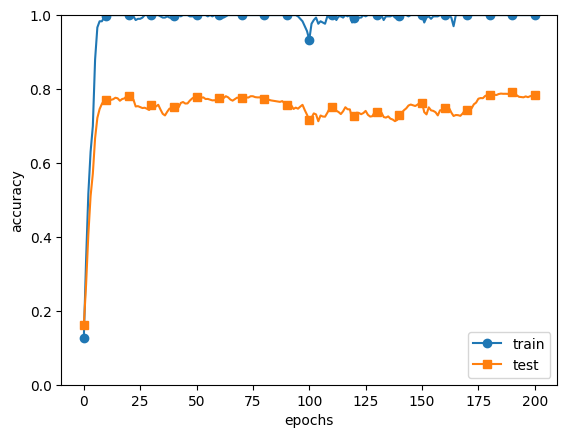

In [27]:
# optimizer를 Adam으로 바꾼 경우
# batch normalization을 적용한 경우

import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                        weight_decay_lambda=0)
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0, use_dropout = False, dropout_ration = 0, use_batchnorm=True)


# optimizer = SGD(lr=0.01)
optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [31]:
import pandas as pd

results = [
    ["SGD",  "non",          1.0000, 0.7373],
    ["SGD",  "weight decay", 0.8567, 0.7177],
    ["SGD",  "dropout",      0.1300, 0.1135],
    ["SGD",  "batch norm",   1.0000, 0.5887],
    ["Adam", "non",          1.0000, 0.7617],
    ["Adam", "weight decay", 0.7067, 0.5145],
    ["Adam", "dropout",      0.7233, 0.5599],
    ["Adam", "batch norm",   1.0000, 0.7826]
]

df = pd.DataFrame(
    results,
    columns=["optimizer", "regularization", "train_acc", "test_acc"]
)

# 일반화 격차
df["gap"] = df["train_acc"] - df["test_acc"]

display(df.round(4))

,optimizer,regularization,train_acc,test_acc,gap
0,SGD,non,1.0000,0.7373,0.2627
1,SGD,weight decay,0.8567,0.7177,0.1390
2,SGD,dropout,0.1300,0.1135,0.0165
3,SGD,batch norm,1.0000,0.5887,0.4113
4,Adam,non,1.0000,0.7617,0.2383
5,Adam,weight decay,0.7067,0.5145,0.1922
6,Adam,dropout,0.7233,0.5599,0.1634
7,Adam,batch norm,1.0000,0.7826,0.2174


In [32]:
display(
    df.pivot(
        index="regularization",
        columns="optimizer",
        values=["train_acc", "test_acc", "gap"]
    ).round(4)
)

train_acc         test_acc             gap        
optimizer           Adam     SGD     Adam     SGD    Adam     SGD
regularization                                                   
batch norm        1.0000  1.0000   0.7826  0.5887  0.2174  0.4113
dropout           0.7233  0.1300   0.5599  0.1135  0.1634  0.0165
non               1.0000  1.0000   0.7617  0.7373  0.2383  0.2627
weight decay      0.7067  0.8567   0.5145  0.7177  0.1922  0.1390